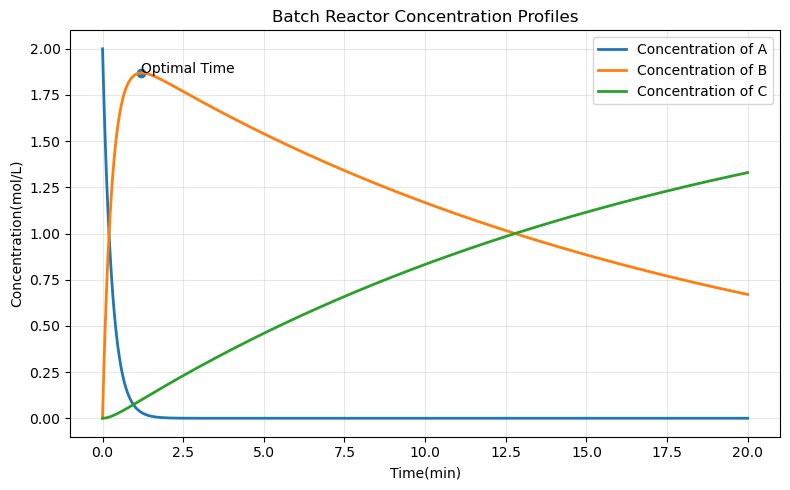

Hence, the maximum concentration of B is reached when t=1.20min or ~72 seconds and it is equal to 1.869mol/L
The Yield at the optimum time is 0.95
The time where the concentration of B remains greater than 1mol/L is between 0.20min and 12.79min, for a total of about 755seconds.
Changing the initial temprature to 330K led to an optimum time of 216seconds and B reached the maximum concentration of 1.888mol/L
Changing the initial temprature to 350K led to an optimum time of 72seconds and B reached the maximum concentration of 1.869mol/L
Changing the initial temprature to 370K led to an optimum time of 29seconds and B reached the maximum concentration of 1.850mol/L


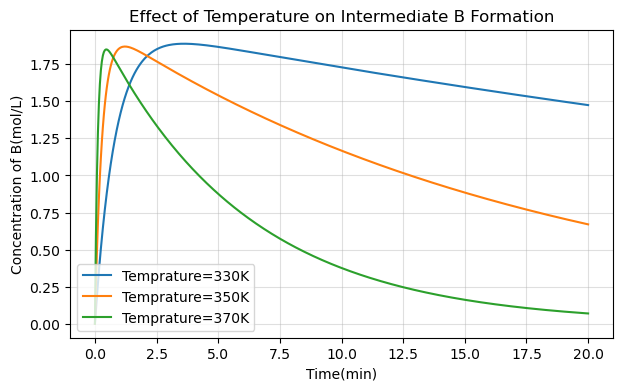

In [18]:
##Batch Reactor Optimization: Maximizing the Desired Intermediate
##The reaction is A-->B-->C, where A is the reactant, B is the desired product and C is undesired by-product.
##The aim is to determine the optimal batch reaction time that maximizes the concentration of B.
##Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
##Given Values
CA0 = 2.0 #mol/L
CB0 = 0 
CC0 = 0
A1 = 1E8 #min⁻¹
Ea1 = 50000 #J/mol
A2 = 5E7 
Ea2 = 60000 
#Assuming isothermal conditions
T=350 #K
R = 8.314
t=np.linspace(0,20,500)
def reactor(y,t,T):
    CA,CB,CC=y
    k1=A1*np.exp(-Ea1/(R*T))
    k2=A2*np.exp(-Ea2/(R*T))
    r1=k1*CA
    r2=k2*CB
    dCAdt=-r1
    dCBdt=r1-r2
    dCCdt=r2
    return [dCAdt,dCBdt,dCCdt]
initial_values=[CA0,CB0,CC0]
Ans=odeint(reactor,initial_values,t,args=(T,))
ConA=Ans[:,0]
ConB=Ans[:,1]
ConC=Ans[:,2]
Con=[ConA,ConB,ConC]
labels=['Concentration of A','Concentration of B','Concentration of C']
##Plotting the Time vs Concentration curve
plt.figure(figsize=(8,5))
for concentrations,ls in zip(Con,labels):
    plt.plot(t,concentrations,label=ls,linewidth=2)
plt.title('Batch Reactor Concentration Profiles')
plt.xlabel('Time(min)')
plt.ylabel('Concentration(mol/L)')
##Finding the time at which the concentration of B is maximum
Highest_index_B=np.argmax(ConB)
Highest_conc_B=ConB[Highest_index_B]
Optimal_time=t[Highest_index_B]
plt.annotate('Optimal Time',(Optimal_time,Highest_conc_B))
plt.scatter(Optimal_time,Highest_conc_B)
plt.grid(True,alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(f'Hence, the maximum concentration of B is reached when t={Optimal_time:.2f}min or ~{(Optimal_time*60):.0f} seconds and it is equal to {Highest_conc_B:.3f}mol/L')
##Calculating Yield at the optimum
CA_at_optimum=ConA[Highest_index_B]
Yield=Highest_conc_B/(CA0-CA_at_optimum)
print(f'The Yield at the optimum time is {Yield:.2f}')
##Finding the time period for which the concentration of B is greater than 1mol/L as too ensure feasible downstream purification. 
t_rising=t[:Highest_index_B]
B_rising=ConB[:Highest_index_B]
t_falling=t[Highest_index_B:]
B_falling=ConB[Highest_index_B:]
time_rising_at_1=np.interp(1.0,B_rising,t_rising)
time_falling_at_1=np.interp(1.0,B_falling[::-1],t_falling[::-1])
print(f'The time where the concentration of B remains greater than 1mol/L is between {(time_rising_at_1):.2f}min and {(time_falling_at_1):.2f}min, for a total of about {(time_falling_at_1-time_rising_at_1)*60:.0f}seconds.')
#Temprature Sensitivity Analysis
Temps=np.array([330,350,370])#K
fig,ax=plt.subplots(figsize=(7,4))
for T in Temps:
    Ans_T=odeint(reactor,initial_values,t,args=(T,))
    ConB_T=Ans_T[:,1]
    Highest_index_B_T=np.argmax(ConB_T)
    Highest_conc_B_T=ConB_T[Highest_index_B_T]
    Optimal_time_T=t[Highest_index_B_T]
    print(f'Changing the initial temprature to {T}K led to an optimum time of {(Optimal_time_T*60):.0f}seconds and B reached the maximum concentration of {Highest_conc_B_T:.3f}mol/L')
    ax.plot(t,ConB_T,label=f'Temprature={T}K')
    ax.set_xlabel('Time(min)')
    ax.set_ylabel('Concentration of B(mol/L)')
    ax.set_title('Effect of Temperature on Intermediate B Formation')
    ax.grid(True,alpha=0.4)
plt.legend()
plt.show()
    